# CNS2025 HW15 — Oja rule trajectories


In [5]:
# @title
import numpy as np
import matplotlib.pyplot as plt

Q = np.array([[1.0, -0.4],
              [-0.4, 1.0]])

alpha = 1.0
tau_w = 1.0
dt = 0.01

In [6]:
# @title
def get_w_trace_oja(w0, Q, *, dt=0.01, tau_w=1.0, alpha=1.0, max_steps=200000, tol=1e-10):
    w = np.array(w0, dtype=float)
    ws = [w.copy()]
    for _ in range(max_steps):
        quad = float(w.T @ Q @ w)
        dw = (Q @ w) - alpha * quad * w
        w_new = w + (dt / tau_w) * dw
        ws.append(w_new.copy())
        if np.linalg.norm(w_new - w) < tol:
            break
        w = w_new
    return np.array(ws)

In [9]:
# @title
eigvals, eigvecs = np.linalg.eigh(Q)
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]
e1, e2 = eigvecs[:, 0], eigvecs[:, 1]

w_star_1 = e1 / np.sqrt(alpha)
w_star_2 = e2 / np.sqrt(alpha)
_ = (eigvals, e1, e2)

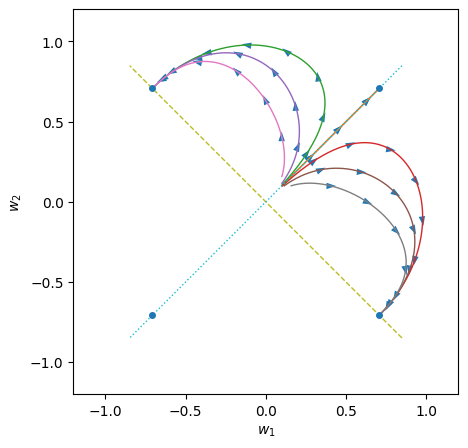

In [8]:
# @title
def _add_arrows(ax, tr, step=0.25):
    last = tr[0]
    for p in tr[1:]:
        if np.sum((p - last) ** 2) >= step**2:
            d = p - last
            r = np.linalg.norm(d)
            if r > 0:
                ax.arrow(p[0], p[1], 0.03*d[0]/r, 0.03*d[1]/r,
                         length_includes_head=True, head_width=0.04, lw=0)
            last = p

fig, ax = plt.subplots(figsize=(5, 5))

w01 = 0.1
for w02 in [0.1, 0.104, 0.115, 0.158]:
    for w0 in ([w01, w02], [w02, w01]):
        tr = get_w_trace_oja(w0, Q, dt=dt, tau_w=tau_w, alpha=alpha)
        ax.plot(tr[:, 0], tr[:, 1], lw=1)
        _add_arrows(ax, tr)

t = np.linspace(-1.2, 1.2, 200)
ax.plot(t*e1[0], t*e1[1], linestyle="--", lw=1)
ax.plot(t*e2[0], t*e2[1], linestyle=":", lw=1)

ax.plot([w_star_1[0], -w_star_1[0], w_star_2[0], -w_star_2[0]],
        [w_star_1[1], -w_star_1[1], w_star_2[1], -w_star_2[1]],
        "o", ms=4)

ax.set_xlabel(r"$w_1$")
ax.set_ylabel(r"$w_2$")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
plt.show()